# **Air Quality Detection (Hazardous or Non-Hazardous)**

**Uploading the File**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [2]:
import warnings
warnings.filterwarnings("ignore")

# **Exploratory Data Analysis**

In [3]:
import pandas as pd

df = pd.read_csv('pollution_us_2000_2016.csv')
print("Shape is : ",df.shape)
df.head()

Shape is :  (1746661, 29)


,Unnamed: 0,State Code,County Code,Site Num,Address,State,County,City,Date Local,NO2 Units,...,SO2 Units,SO2 Mean,SO2 1st Max Value,SO2 1st Max Hour,SO2 AQI,CO Units,CO Mean,CO 1st Max Value,CO 1st Max Hour,CO AQI
0,0,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,1.145833,4.2,21,NaN
1,1,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,3.000000,9.0,21,13.0,Parts per million,0.878947,2.2,23,25.0
2,2,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,1.145833,4.2,21,NaN
3,3,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-01,Parts per billion,...,Parts per billion,2.975000,6.6,23,NaN,Parts per million,0.878947,2.2,23,25.0
4,4,4,13,3002,1645 E ROOSEVELT ST-CENTRAL PHOENIX STN,Arizona,Maricopa,Phoenix,2000-01-02,Parts per billion,...,Parts per billion,1.958333,3.0,22,4.0,Parts per million,0.850000,1.6,23,NaN


In [4]:
print("Columns:\n", df.columns.tolist())
df.info()          # dtypes + non‑null counts

Columns:
 ['Unnamed: 0', 'State Code', 'County Code', 'Site Num', 'Address', 'State', 'County', 'City', 'Date Local', 'NO2 Units', 'NO2 Mean', 'NO2 1st Max Value', 'NO2 1st Max Hour', 'NO2 AQI', 'O3 Units', 'O3 Mean', 'O3 1st Max Value', 'O3 1st Max Hour', 'O3 AQI', 'SO2 Units', 'SO2 Mean', 'SO2 1st Max Value', 'SO2 1st Max Hour', 'SO2 AQI', 'CO Units', 'CO Mean', 'CO 1st Max Value', 'CO 1st Max Hour', 'CO AQI']
<class 'pandas.DataFrame'>
RangeIndex: 1746661 entries, 0 to 1746660
Data columns (total 29 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Unnamed: 0         int64  
 1   State Code         int64  
 2   County Code        int64  
 3   Site Num           int64  
 4   Address            str    
 5   State              str    
 6   County             str    
 7   City               str    
 8   Date Local         str    
 9   NO2 Units          str    
 10  NO2 Mean           float64
 11  NO2 1st Max Value  float64
 12  NO2 1st Max Hour   int64  
 1

# **Handling Missing Values**

CO AQI     873323
SO2 AQI    872907
dtype: int64


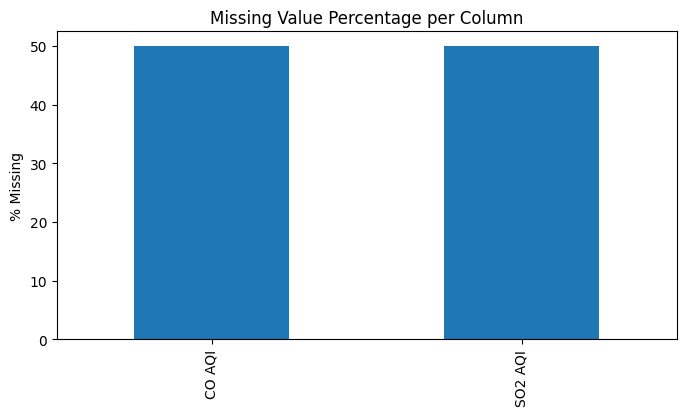

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0])                # only columns with missing values

# barplot of null counts
nulls = nulls[nulls > 0] / len(df) * 100
plt.figure(figsize=(8,4))
nulls.plot(kind='bar')
plt.ylabel('% Missing'); plt.title('Missing Value Percentage per Column')
plt.show()

In [6]:
df['CO AQI'] = df.groupby('State')['CO AQI'].transform(lambda x: x.fillna(x.median()))

In [7]:
df['SO2 AQI'] = df.groupby('State')['SO2 AQI'].transform(lambda x: x.fillna(x.median()))

In [8]:
nulls = df.isna().sum().sort_values(ascending=False)
print(nulls[nulls > 0])                # only columns with missing values

Series([], dtype: int64)


# **Checking for Duplicates**

In [9]:
# Check total duplicates
print("Duplicate rows:", df.duplicated().sum())

# Drop duplicate rows
df = df.drop_duplicates()

Duplicate rows: 0


# **EDA with statistics and Graphs**

In [10]:
df.describe().T   # quick summary statistics

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1746661.0,54714.136753,33729.076302,0.0000,25753.000000,53045.000000,80336.000000,134575.000000
State Code,1746661.0,22.309065,17.256205,1.0000,6.000000,17.000000,40.000000,80.000000
County Code,1746661.0,71.693807,79.480231,1.0000,17.000000,59.000000,97.000000,650.000000
Site Num,1746661.0,1118.214373,2003.103069,1.0000,9.000000,60.000000,1039.000000,9997.000000
NO2 Mean,1746661.0,12.821930,9.504814,-2.0000,5.750000,10.739130,17.713636,139.541667
NO2 1st Max Value,1746661.0,25.414848,15.999630,-2.0000,13.000000,24.000000,35.700000,267.000000
NO2 1st Max Hour,1746661.0,11.731023,7.877501,0.0000,5.000000,9.000000,20.000000,23.000000
NO2 AQI,1746661.0,23.898217,15.162805,0.0000,12.000000,23.000000,33.000000,132.000000
O3 Mean,1746661.0,0.026125,0.011370,0.0000,0.017875,0.025875,0.033917,0.095083
O3 1st Max Value,1746661.0,0.039203,0.015344,0.0000,0.029000,0.038000,0.048000,0.141000


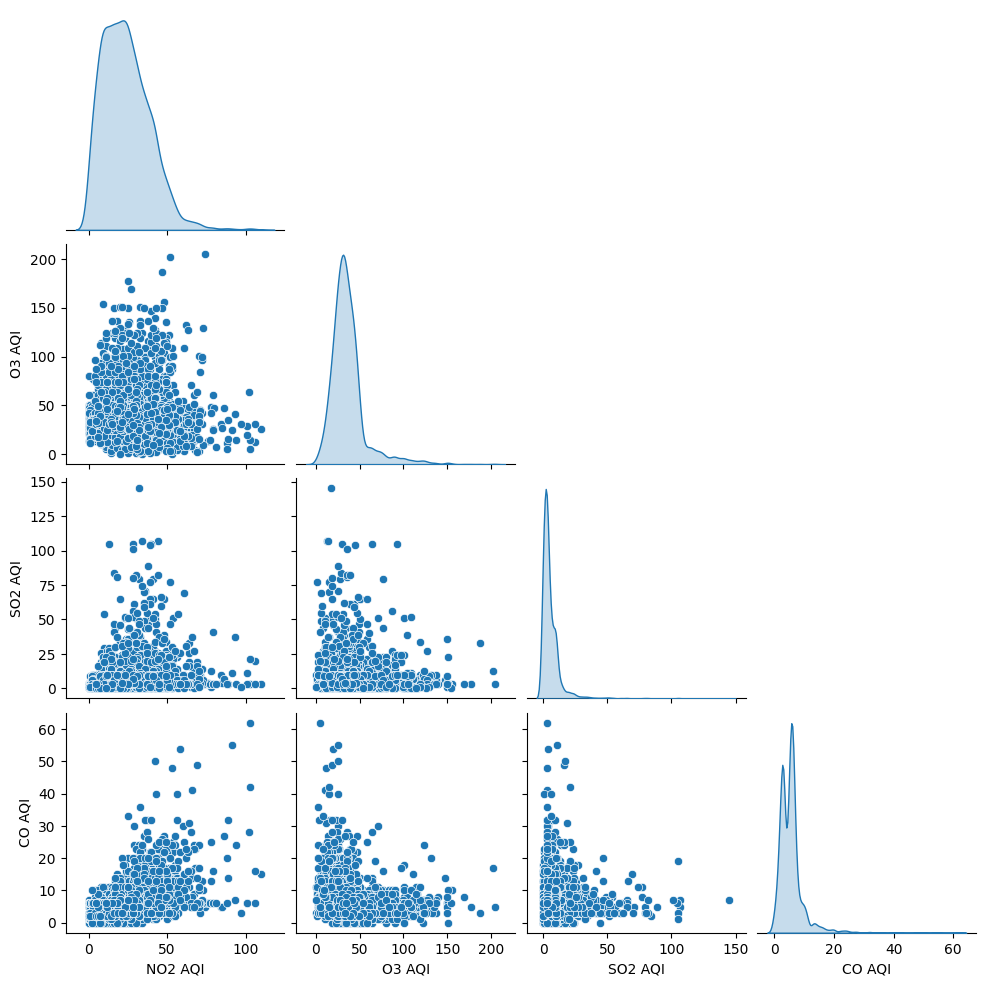

In [11]:
sample = df.sample(5000, random_state=42)
sns.pairplot(
    sample[['NO2 AQI','O3 AQI','SO2 AQI','CO AQI']],
    corner=True, diag_kind='kde'
)
plt.show()

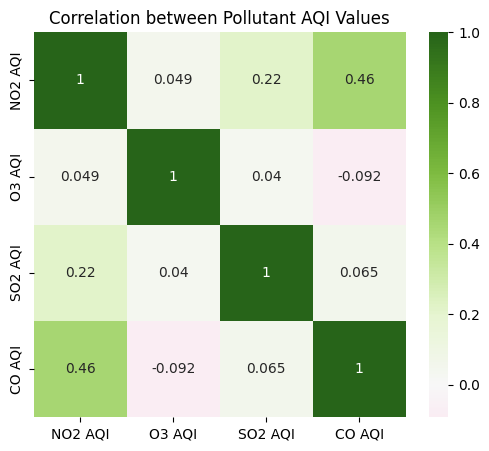

In [12]:
plt.figure(figsize=(6,5))
sns.heatmap(df[['NO2 AQI','O3 AQI','SO2 AQI','CO AQI']].corr(),
            cmap='PiYG', center=0, annot=True)
plt.title('Correlation between Pollutant AQI Values')
plt.show()

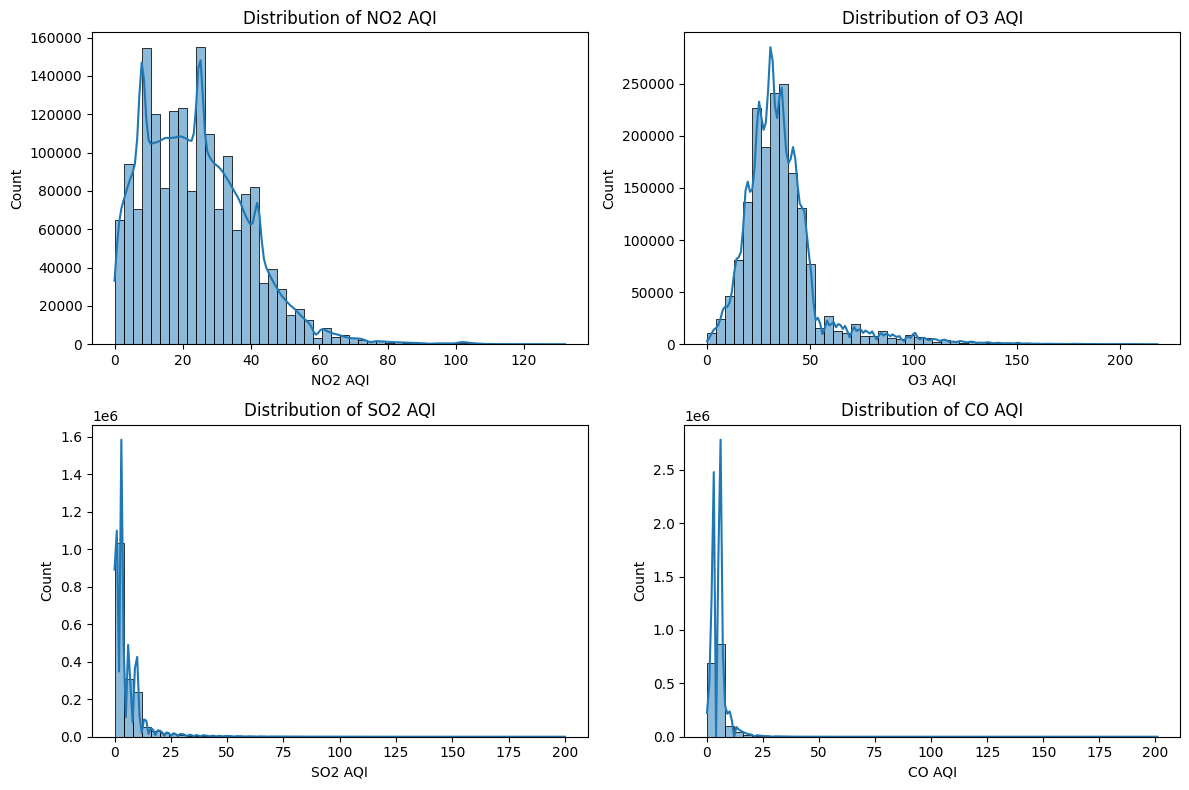

In [13]:
aqi_cols = ['NO2 AQI','O3 AQI','SO2 AQI','CO AQI']
fig, axes = plt.subplots(2,2, figsize=(12,8))
axes = axes.ravel()

for i, col in enumerate(aqi_cols):
    sns.histplot(df[col], bins=50, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [14]:
# Dates to datetime
df['Date Local'] = pd.to_datetime(df['Date Local'])

# Remove duplicate rows
df = df.drop_duplicates()

# Missing numeric values to median of each column
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Simple outlier cap (IQR)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

In [15]:
# Split date
df['Year']  = df['Date Local'].dt.year
df['Month'] = df['Date Local'].dt.month

# Hazardous flag (any pollutant AQI > 100)
aqi_cols = [c for c in df.columns if c.endswith('AQI')]
df['Hazardous'] = (df[aqi_cols].max(axis=1) > 100).astype(int)

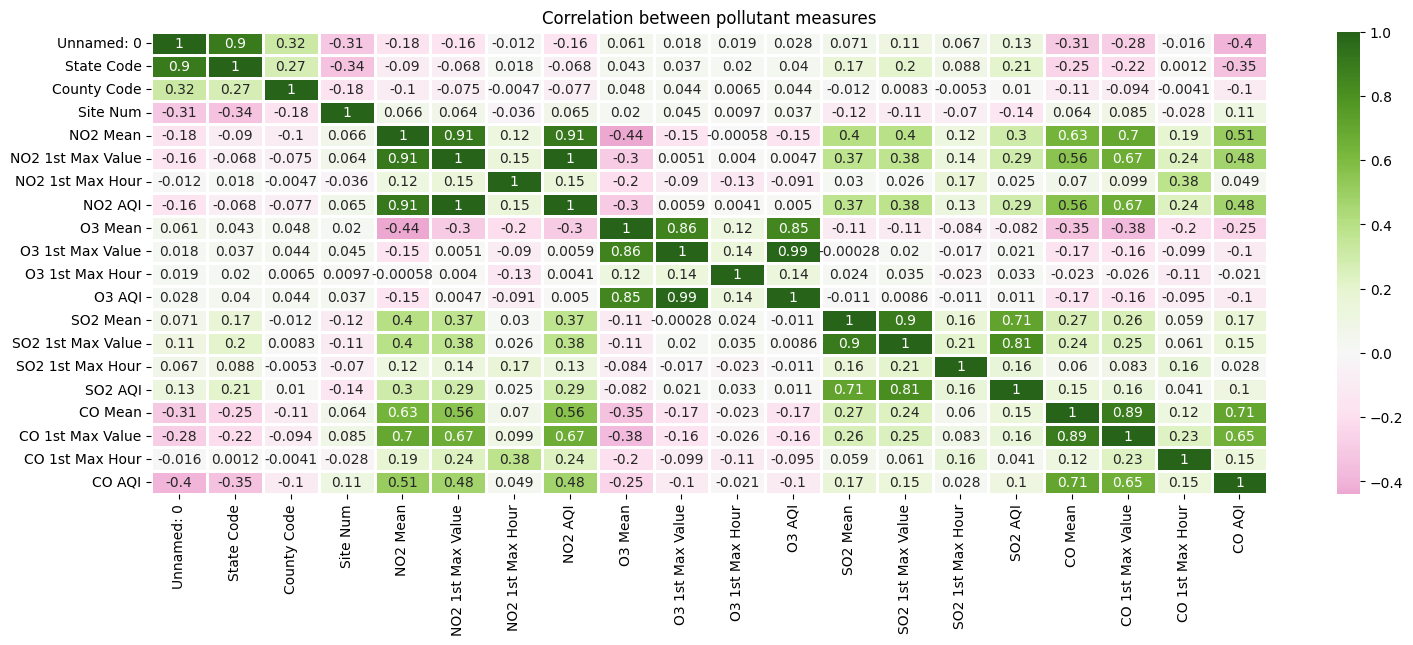

In [16]:
# Correlation heat‑map
plt.figure(figsize=(18, 6))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    cmap='PiYG',
    center=0,
    linewidths=1,
    linecolor='white'
)
plt.title('Correlation between pollutant measures')
plt.show()

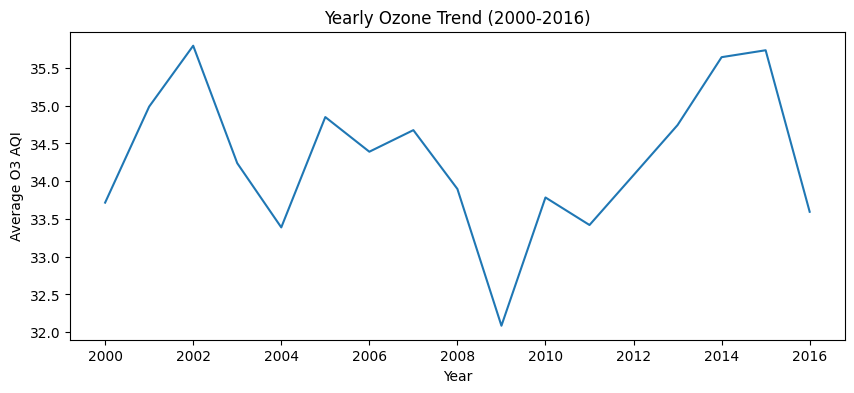

In [17]:
df['Date Local'] = pd.to_datetime(df['Date Local'])
df['Year'] = df['Date Local'].dt.year

(df.groupby('Year')['O3 AQI'].mean()
   .plot(figsize=(10,4)))
plt.ylabel('Average O3 AQI'); plt.title('Yearly Ozone Trend (2000‑2016)')
plt.show()

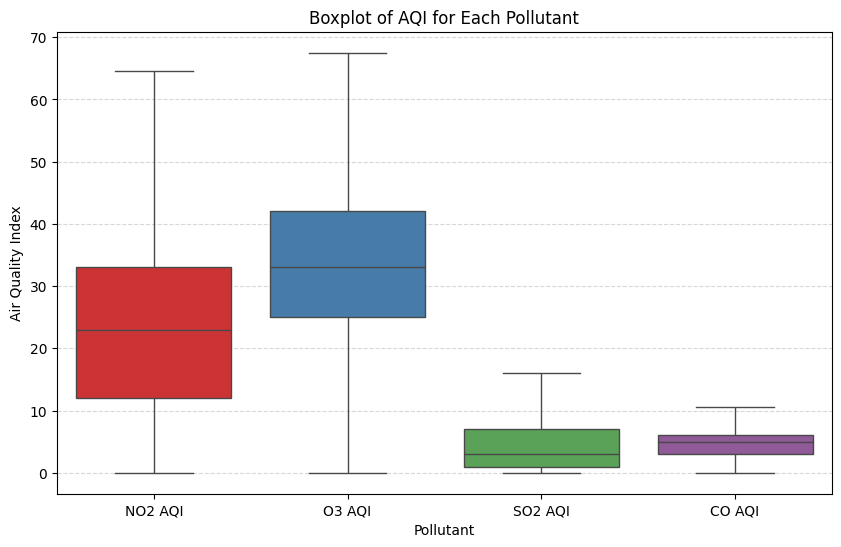

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# Focus on AQI columns
aqi_cols = ['NO2 AQI', 'O3 AQI', 'SO2 AQI', 'CO AQI']

# Create a long-form DataFrame for Seaborn
df_aqi = df[aqi_cols].copy()
df_aqi = df_aqi.melt(var_name='Pollutant', value_name='AQI')

plt.figure(figsize=(10,6))
sns.boxplot(x='Pollutant', y='AQI', data=df_aqi, palette='Set1')
plt.title('Boxplot of AQI for Each Pollutant')
plt.ylabel('Air Quality Index')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

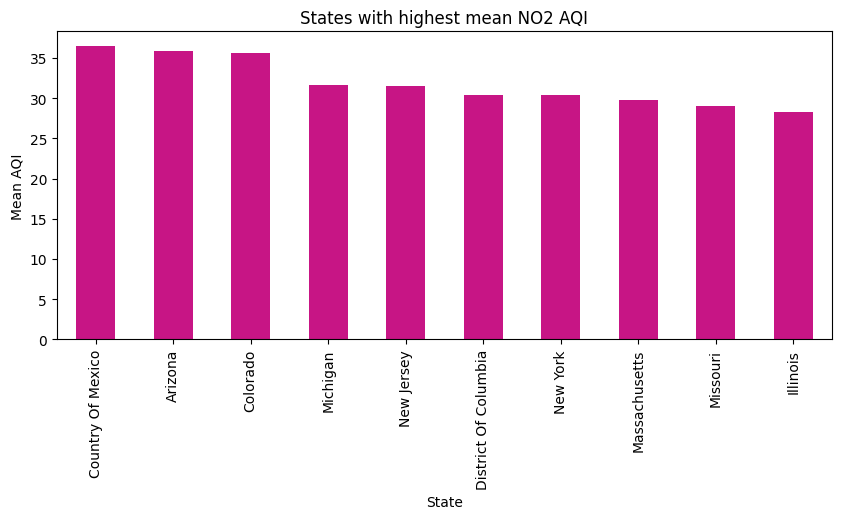

In [19]:
# Top 10 states by mean NO2 AQI
(df.groupby('State')['NO2 AQI'].mean()
   .sort_values(ascending=False).head(10)
   .plot(kind='bar', figsize=(10,4), color='mediumvioletred'))
plt.title('States with highest mean NO2 AQI')
plt.ylabel('Mean AQI')
plt.show()

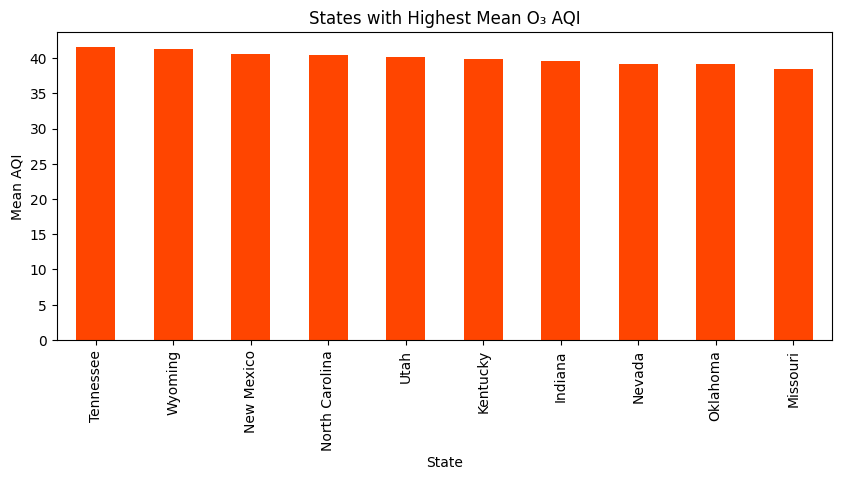

In [20]:
# Top 10 states by mean O3 AQI
(df.groupby('State')['O3 AQI'].mean()
   .sort_values(ascending=False).head(10)
   .plot(kind='bar', figsize=(10,4), color='orangered'))

plt.title('States with Highest Mean O₃ AQI')
plt.ylabel('Mean AQI')
plt.show()

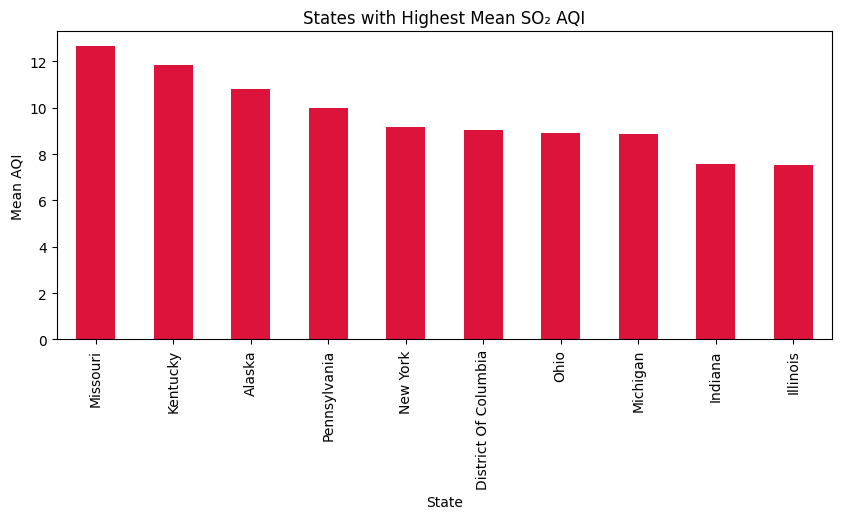

In [21]:
# Top 10 states by mean SO2 AQI
(df.groupby('State')['SO2 AQI'].mean()
   .sort_values(ascending=False).head(10)
   .plot(kind='bar', figsize=(10,4), color='crimson'))

plt.title('States with Highest Mean SO₂ AQI')
plt.ylabel('Mean AQI')
plt.show()

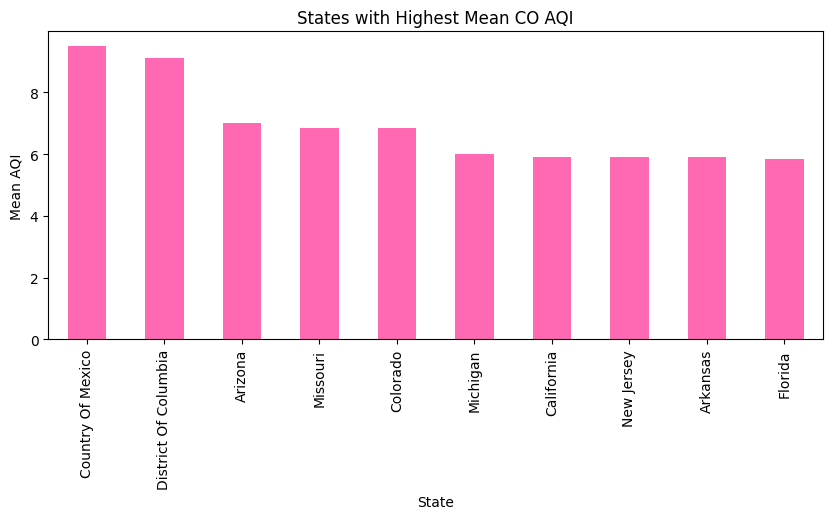

In [22]:
# Top 10 states by mean CO AQI
(df.groupby('State')['CO AQI'].mean()
   .sort_values(ascending=False).head(10)
   .plot(kind='bar', figsize=(10,4), color='hotpink'))

plt.title('States with Highest Mean CO AQI')
plt.ylabel('Mean AQI')
plt.show()

# **Building and Evaluating Machine Learning Model**

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler

features   = ['NO2 Mean','O3 Mean','SO2 Mean','CO Mean','Year','Month']
X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['Hazardous'], test_size=0.2, random_state=42, stratify=df['Hazardous'])

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

In [24]:
print(df['Hazardous'].value_counts())

Hazardous
0    1746661
Name: count, dtype: int64


In [25]:
df['Hazardous'] = (df[aqi_cols].max(axis=1) > 50).astype(int)

In [26]:
print(df['Hazardous'].value_counts())

Hazardous
0    1492673
1     253988
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features], df['Hazardous'],
    test_size=0.2,
    random_state=42,
    stratify=df['Hazardous']
)

In [28]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

# **Logistic Regression**

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics      import accuracy_score, classification_report

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train_sc, y_train)

y_pred_lr = logreg.predict(X_test_sc)
print('Logistic Regression accuracy:', accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression accuracy: 0.9070714762132407
              precision    recall  f1-score   support

           0       0.93      0.97      0.95    298535
           1       0.75      0.55      0.63     50798

    accuracy                           0.91    349333
   macro avg       0.84      0.76      0.79    349333
weighted avg       0.90      0.91      0.90    349333



# **Decision Tree**

In [30]:
from sklearn.tree   import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
print('Decision Tree accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 0.9193062207120427
              precision    recall  f1-score   support

           0       0.94      0.97      0.95    298535
           1       0.78      0.63      0.69     50798

    accuracy                           0.92    349333
   macro avg       0.86      0.80      0.82    349333
weighted avg       0.91      0.92      0.92    349333



In [31]:
from sklearn.tree   import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
print('Decision Tree accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 0.9234484002370231
              precision    recall  f1-score   support

           0       0.94      0.97      0.96    298535
           1       0.78      0.65      0.71     50798

    accuracy                           0.92    349333
   macro avg       0.86      0.81      0.83    349333
weighted avg       0.92      0.92      0.92    349333



In [32]:
from sklearn.tree   import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
print('Decision Tree accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 0.9154044994317743
              precision    recall  f1-score   support

           0       0.94      0.96      0.95    298535
           1       0.75      0.63      0.68     50798

    accuracy                           0.92    349333
   macro avg       0.84      0.80      0.82    349333
weighted avg       0.91      0.92      0.91    349333



In [33]:
from sklearn.tree   import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt = DecisionTreeClassifier(max_depth=12, random_state=42)
dt.fit(X_train_sc, y_train)

y_pred_dt = dt.predict(X_test_sc)
print('Decision Tree accuracy:', accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Decision Tree accuracy: 0.9304445901188837
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    298535
           1       0.80      0.69      0.74     50798

    accuracy                           0.93    349333
   macro avg       0.88      0.83      0.85    349333
weighted avg       0.93      0.93      0.93    349333



Increasing the depth of the Decision Tree further might result in overfitting, hence we stop here.

# **K- Nearest Neighbors**

Optimal k ≈ 15  |  Accuracy on sample = 0.882


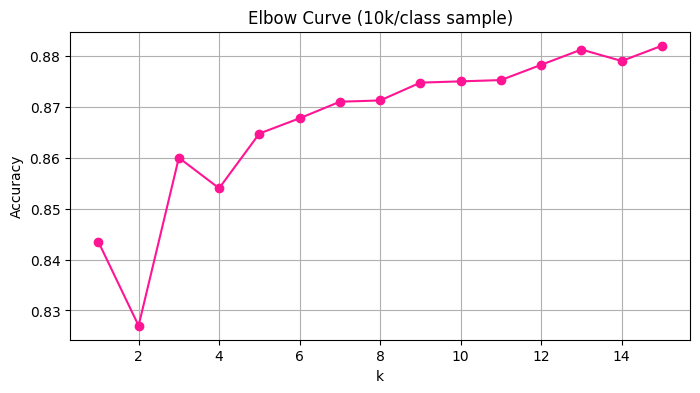

In [49]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.metrics        import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1) --------  sample 10 000 rows per class  -----------------
df_sample = df.groupby('Hazardous', group_keys=False).sample(
    n=10000, replace=True, random_state=42
)
X_small   = df_sample[features]
y_small   = df_sample['Hazardous']

# 2) --------  split + scale  -----------------
X_tr, X_te, y_tr, y_te = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=42)

sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

# 3) --------  elbow loop (k = 1…15)  -----------------
k_range = range(1, 16)
acc     = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k, algorithm='auto')
    knn.fit(X_tr_sc, y_tr)
    acc.append(accuracy_score(y_te, knn.predict(X_te_sc)))

opt_k = k_range[int(np.argmax(acc))]
print(f"Optimal k ≈ {opt_k}  |  Accuracy on sample = {max(acc):.3f}")

# 4) --------  plot  -----------------
plt.figure(figsize=(8,4))
plt.plot(k_range, acc, marker='o', color='deeppink')
plt.xlabel('k'); plt.ylabel('Accuracy'); plt.title('Elbow Curve (10k/class sample)')
plt.grid(True); plt.show()

In [50]:
# Train final KNN on the *full* scaled data using the chosen k
knn_final = KNeighborsClassifier(n_neighbors=opt_k)
knn_final.fit(X_train_sc, y_train)
y_pred_knn = knn.predict(X_test_sc)

KNN (k=15) Accuracy: 0.695
              precision    recall  f1-score   support

           0       1.00      0.64      0.78    298535
           1       0.32      0.99      0.48     50798

    accuracy                           0.69    349333
   macro avg       0.66      0.82      0.63    349333
weighted avg       0.90      0.69      0.74    349333



<Figure size 600x500 with 0 Axes>

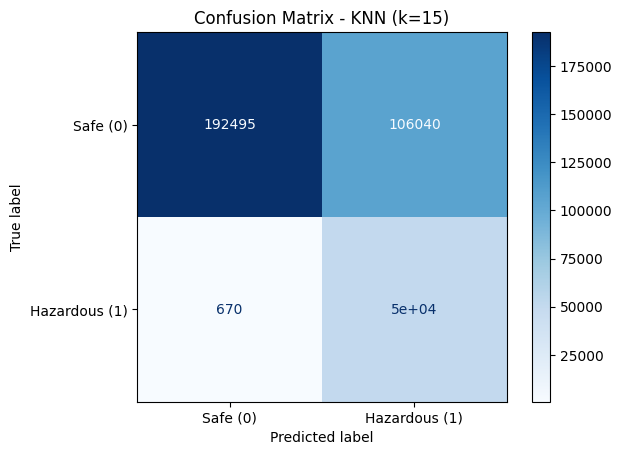

In [51]:
print(f"KNN (k={opt_k}) Accuracy: {accuracy_score(y_test, y_pred_knn):.3f}")
print(classification_report(y_test, y_pred_knn))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Safe (0)', 'Hazardous (1)'])

plt.figure(figsize=(6,5))
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - KNN (k={opt_k})')
plt.grid(False)
plt.show()

# **Interpretation**:

**Decision Tree** clearly outperforms both Logistic Regression and KNN in:

Overall Accuracy (**93.04%**)

Precision, Recall, and F1-score for classifying Hazardous areas (class 0 and 1)

Decision Tree not only maintains *high accuracy* for safe areas, but also identifies hazardous areas better — making it *more suitable for real-world pollution risk detection.*